In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, d_model):
        super().__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size."
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(3, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        """(B,C,H,W) -> (B, d_model, H_patches, W_patches) -> (B, num_patches, d_model)"""
        return self.proj(x).flatten(2).transpose(1, 2)


class VisionTransformer(nn.Module):
    def __init__(self,image_size, patch_size, num_classes, d_model, depth, num_heads):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, d_model)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=int(d_model), batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x: torch.Tensor):
        batch_size = x.shape[0]
        patches = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, patches], dim=1)
        x = x + self.pos_embed

        x = self.encoder(x)
        x = self.norm(x)

        cls_token_final = x[:, 0]
        out = self.head(cls_token_final)

        return out

In [4]:
def get_dataloaders(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Standard normalization for CIFAR
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

In [5]:
def train_model(model, trainloader, testloader, epochs=5, lr=3e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Training on device: {device}")
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # AdamW is preferred for ViTs

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)
        history['train_loss'].append(avg_train_loss)

        # Evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_train_loss:.4f} - Test Acc: {test_acc:.2f}%")

    return history

In [6]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
    ax1.set_title('Training Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history['test_acc'], label='Test Accuracy', color='green', marker='o')
    ax2.set_title('Test Accuracy over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

100.0%
c:\Users\Utente\University\Magistrale\Primo Anno\Computer Vision\Computer_Vision\Labs\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training on device: cpu
Epoch [1/10] - Loss: 1.9177 - Test Acc: 36.88%
Epoch [2/10] - Loss: 1.6912 - Test Acc: 42.45%
Epoch [3/10] - Loss: 1.5792 - Test Acc: 44.56%
Epoch [4/10] - Loss: 1.5020 - Test Acc: 47.86%
Epoch [5/10] - Loss: 1.4425 - Test Acc: 49.02%
Epoch [6/10] - Loss: 1.3937 - Test Acc: 50.75%
Epoch [7/10] - Loss: 1.3582 - Test Acc: 52.11%
Epoch [8/10] - Loss: 1.3289 - Test Acc: 52.32%
Epoch [9/10] - Loss: 1.2977 - Test Acc: 53.70%
Epoch [10/10] - Loss: 1.2741 - Test Acc: 54.25%


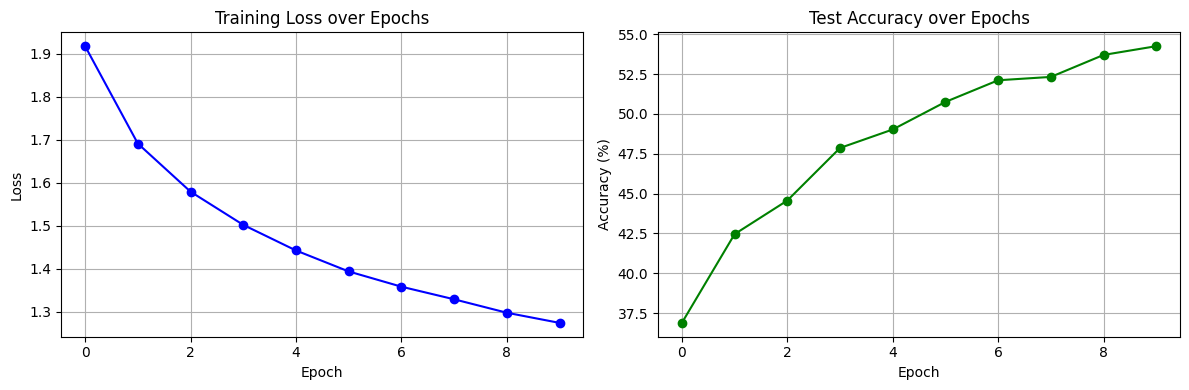

In [7]:
model = VisionTransformer(
        image_size=32, 
        patch_size=8, 
        num_classes=10, 
        d_model=64, 
        depth=3, 
        num_heads=4
    )
    
trainloader, testloader = get_dataloaders(batch_size=128)

# Train for 10 epochs (ViTs usually take a bit longer to converge than CNNs)
history = train_model(model, trainloader, testloader, epochs=10)

# Plot the results
plot_history(history)